<a href="https://colab.research.google.com/github/veridelisi/The-First-Bank-of-United-States-1791-1793-/blob/main/Employment_rates_by_educational_attainment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd
from io import StringIO
from google.colab import files



# ============================================================
# 1. OECD DATA
# ============================================================

url = (
    "https://sdmx.oecd.org/public/rest/v1/data/"
    "OECD.ELS.IMD,DSD_MIG@DF_MIG_EMP_EDU,1.0/"
    "?startPeriod=2010"
    "&endPeriod=2024"
    "&dimensionAtObservation=AllDimensions"
)

headers = {"Accept": "text/csv"}

response = requests.get(url, headers=headers, timeout=180)
response.raise_for_status()

df = pd.read_csv(StringIO(response.text))

# ============================================================
# 1. EDUCATION LEVEL CODES
# ============================================================

education = {
    "_T": "Total",
    "ISCED11_0T2": "Low",
    "ISCED11_3_4": "Medium",
    "ISCED11_5T8": "Tertiary"
}

birth = {
    "FB": "Foreign",
    "NB": "Native"
}

# ============================================================
# 2. CLEAN AND FILTER THE DATA
# ============================================================

# Remove possible leading/trailing spaces
df["EDUCATION_LEV"] = df["EDUCATION_LEV"].astype(str).str.strip()
df["BIRTH_PLACE"] = df["BIRTH_PLACE"].astype(str).str.strip()

# Select:
# - Employment rate
# - Total population (male + female)
# - Foreign-born and native-born
# - Total + three education levels

filtered = df[
    (df["MEASURE"] == "EMP_WAP") &
    (df["SEX"] == "_T") &
    (df["BIRTH_PLACE"].isin(["FB", "NB"])) &
    (df["EDUCATION_LEV"].isin(education.keys()))
].copy()

# Create readable education labels
filtered["EDU"] = filtered["EDUCATION_LEV"].map(education)

# Create readable birthplace labels
filtered["BIRTH"] = filtered["BIRTH_PLACE"].map(birth)

# ============================================================
# 3. CONVERT TO COUNTRY-YEAR WIDE FORMAT
# ============================================================

result = filtered.pivot_table(
    index=["REF_AREA", "TIME_PERIOD"],
    columns=["EDU", "BIRTH"],
    values="OBS_VALUE",
    aggfunc="first"
).reset_index()

# Flatten multi-level column names
result.columns = [
    "_".join([str(x) for x in col if str(x) != ""]).strip("_")
    if isinstance(col, tuple)
    else col
    for col in result.columns
]

# ============================================================
# 4. SELECT AND ORDER THE 8 EMPLOYMENT VARIABLES
# ============================================================

columns = [
    "REF_AREA",
    "TIME_PERIOD",

    "Total_Foreign",
    "Total_Native",

    "Low_Foreign",
    "Low_Native",

    "Medium_Foreign",
    "Medium_Native",

    "Tertiary_Foreign",
    "Tertiary_Native"
]

result = result[columns]

# ============================================================
# 5. ROUND EMPLOYMENT RATES TO ONE DECIMAL PLACE
# Example: 77.178551 -> 77.2
# ============================================================

value_columns = columns[2:]

result[value_columns] = result[value_columns].round(1)

# Sort by country and year
result = result.sort_values(
    ["REF_AREA", "TIME_PERIOD"]
).reset_index(drop=True)

# ============================================================
# 6. DISPLAY THE FINAL DATASET
# ============================================================

print("Number of country-year observations:", len(result))

print("\nFinal columns:")
print(result.columns.tolist())

display(result.head(30))

Number of country-year observations: 345

Final columns:
['REF_AREA', 'TIME_PERIOD', 'Total_Foreign', 'Total_Native', 'Low_Foreign', 'Low_Native', 'Medium_Foreign', 'Medium_Native', 'Tertiary_Foreign', 'Tertiary_Native']


,REF_AREA,TIME_PERIOD,Total_Foreign,Total_Native,Low_Foreign,Low_Native,Medium_Foreign,Medium_Native,Tertiary_Foreign,Tertiary_Native
0,AUS,2015,72.3,77.2,NaN,NaN,NaN,NaN,NaN,NaN
1,AUS,2016,72.6,77.6,NaN,NaN,NaN,NaN,NaN,NaN
2,AUS,2017,73.7,78.1,NaN,NaN,NaN,NaN,NaN,NaN
3,AUS,2018,74.5,78.6,NaN,NaN,NaN,NaN,NaN,NaN
4,AUS,2019,72.1,75.4,NaN,NaN,NaN,NaN,NaN,NaN
5,AUS,2020,70.7,73.4,NaN,NaN,NaN,NaN,NaN,NaN
6,AUS,2021,73.8,75.2,NaN,NaN,NaN,NaN,NaN,NaN
7,AUS,2022,77.0,77.1,NaN,NaN,NaN,NaN,NaN,NaN
8,AUS,2023,77.5,77.3,NaN,NaN,NaN,NaN,NaN,NaN
9,AUS,2024,77.3,77.2,NaN,NaN,NaN,NaN,NaN,NaN


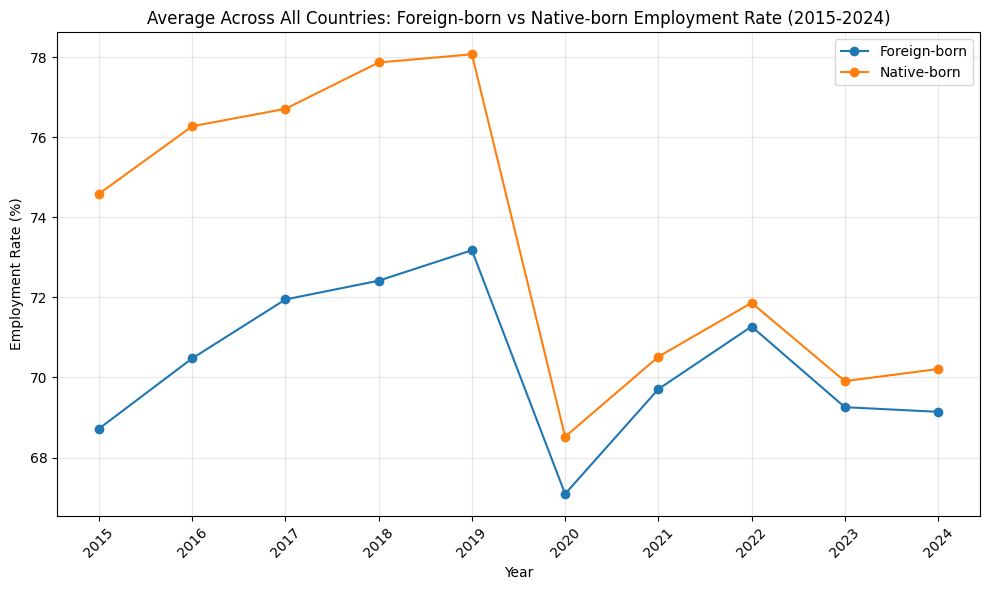

Methodology — Chart 1:
For each year, the employment rate is averaged across all countries that
reported a value for that year. Countries with a missing (NaN) value in a
given year are excluded from that year's average only — they are not treated
as zero and do not drag the average down. Countries contributing per year:
             Total_Foreign  Total_Native
TIME_PERIOD                             
2015                    33            33
2016                    31            31
2017                    31            31
2018                    30            30
2019                    31            31
2020                    35            35
2021                    35            35
2022                    36            36
2023                    38            38
2024                    36            36



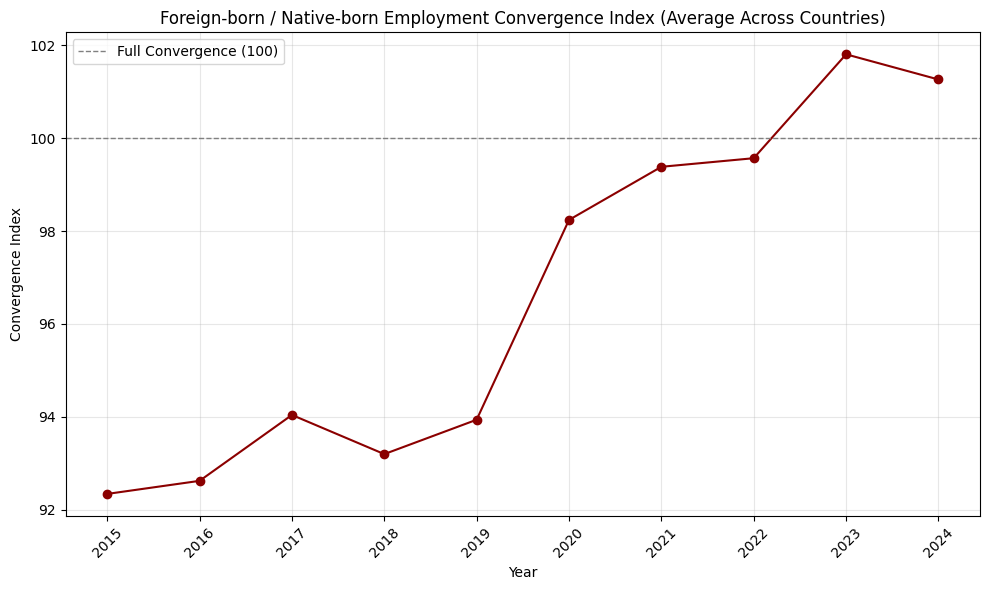

Methodology — Chart 2:
The convergence index is computed per country-year as (Foreign / Native) * 100.
Rows where Native is 0 or NaN produce an undefined ratio (NaN or inf); these are
converted to NaN and excluded before averaging, so they cannot bias the yearly mean.
The plotted line is the mean of the index across all countries with a valid value
in that year. Countries contributing per year:
TIME_PERIOD
2015    33
2016    31
2017    31
2018    30
2019    31
2020    35
2021    35
2022    36
2023    38
2024    36
Name: Convergence_Index, dtype: int64



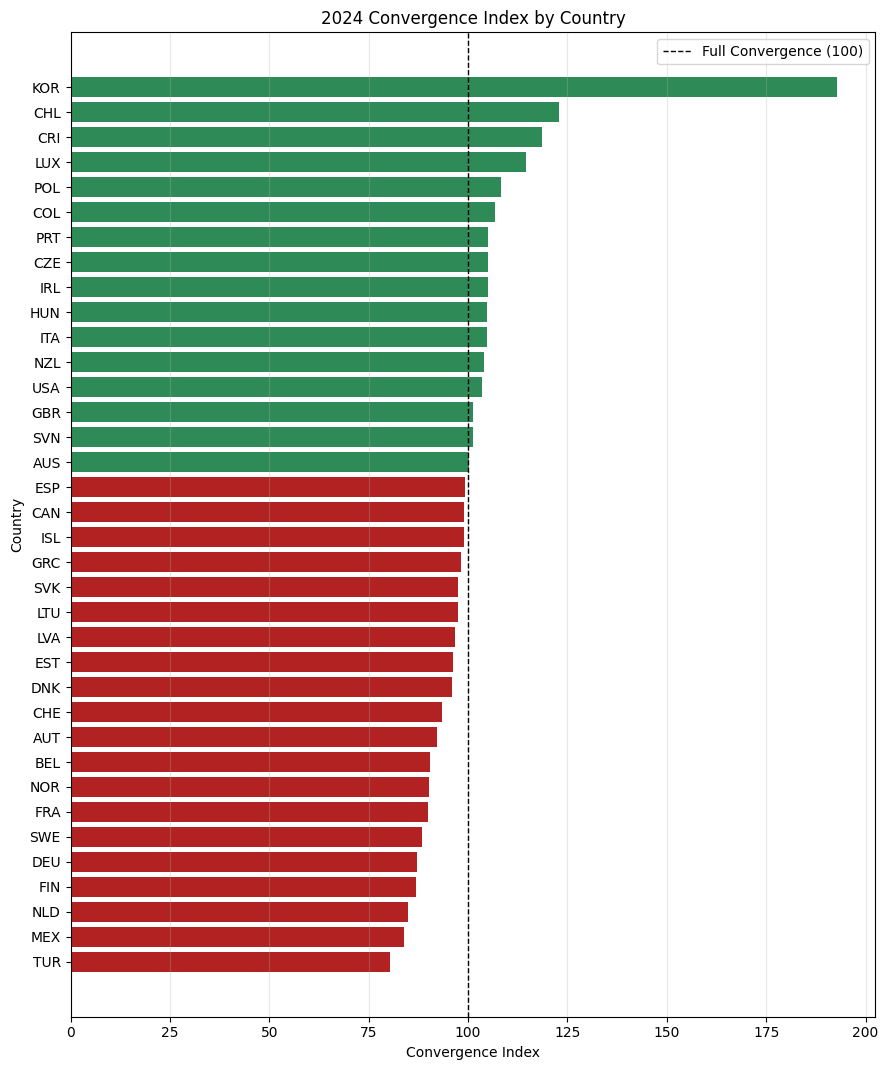

Methodology — Chart 3:
Shows each country's 2024 convergence index. Countries with a missing or
undefined value for 2024 are excluded from the chart entirely (not shown as 0),
so the bars reflect only countries with valid data for that year.
Countries shown: 36 out of 39 total in the dataset.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 0. YEAR FILTER (2015-2024)
# ============================================================

result["TIME_PERIOD"] = result["TIME_PERIOD"].astype(int)
res = result[(result["TIME_PERIOD"] >= 2015) & (result["TIME_PERIOD"] <= 2024)].copy()

# ============================================================
# 1. CHART: AVERAGE ACROSS ALL COUNTRIES (Total_Foreign vs Total_Native)
# NOTE: pandas' .mean() ignores NaN by default (skipna=True), so
# countries with missing values for a given year are simply excluded
# from that year's average rather than pulling it toward zero.
# ============================================================

yearly_avg = res.groupby("TIME_PERIOD")[["Total_Foreign", "Total_Native"]].mean()

# how many countries actually contributed to each year's average
coverage_total = res.groupby("TIME_PERIOD")[["Total_Foreign", "Total_Native"]].apply(
    lambda d: d.notna().sum()
)

plt.figure(figsize=(10, 6))
plt.plot(yearly_avg.index, yearly_avg["Total_Foreign"], marker="o", label="Foreign-born")
plt.plot(yearly_avg.index, yearly_avg["Total_Native"], marker="o", label="Native-born")
plt.title("Average Across All Countries: Foreign-born vs Native-born Employment Rate (2015-2024)")
plt.xlabel("Year")
plt.ylabel("Employment Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(yearly_avg.index, rotation=45)
plt.tight_layout()
plt.show()

print("Methodology — Chart 1:")
print("For each year, the employment rate is averaged across all countries that")
print("reported a value for that year. Countries with a missing (NaN) value in a")
print("given year are excluded from that year's average only — they are not treated")
print("as zero and do not drag the average down. Countries contributing per year:")
print(coverage_total)
print()

# ============================================================
# 2. CONVERGENCE INDEX
# Index = (Foreign / Native) * 100
# 100  -> full convergence (foreign = native)
# <100 -> foreign-born lag behind native-born
# >100 -> foreign-born exceed native-born
#
# NOTE: if Native = 0 or NaN, the ratio becomes NaN/inf and would
# distort the average if left in. These cases are explicitly removed
# before the index is averaged across countries.
# ============================================================

ratio = res["Total_Foreign"] / res["Total_Native"].replace(0, np.nan)
ratio = ratio.replace([np.inf, -np.inf], np.nan)
res["Convergence_Index"] = ratio * 100

index_by_year = res.groupby("TIME_PERIOD")["Convergence_Index"].mean()
coverage_index = res.groupby("TIME_PERIOD")["Convergence_Index"].apply(lambda s: s.notna().sum())

plt.figure(figsize=(10, 6))
plt.plot(index_by_year.index, index_by_year.values, marker="o", color="darkred")
plt.axhline(100, color="gray", linestyle="--", linewidth=1, label="Full Convergence (100)")
plt.title("Foreign-born / Native-born Employment Convergence Index (Average Across Countries)")
plt.xlabel("Year")
plt.ylabel("Convergence Index")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(index_by_year.index, rotation=45)
plt.tight_layout()
plt.show()

print("Methodology — Chart 2:")
print("The convergence index is computed per country-year as (Foreign / Native) * 100.")
print("Rows where Native is 0 or NaN produce an undefined ratio (NaN or inf); these are")
print("converted to NaN and excluded before averaging, so they cannot bias the yearly mean.")
print("The plotted line is the mean of the index across all countries with a valid value")
print("in that year. Countries contributing per year:")
print(coverage_index)
print()

# ============================================================
# 3. 2024: CONVERGENCE INDEX BY COUNTRY (Horizontal Bar Chart)
# Countries with no valid index value in 2024 (NaN) are dropped
# rather than shown as zero.
# ============================================================

data_2024 = res[res["TIME_PERIOD"] == 2024][["REF_AREA", "Convergence_Index"]].dropna()
data_2024 = data_2024.sort_values("Convergence_Index")

plt.figure(figsize=(9, max(6, len(data_2024) * 0.3)))
colors = ["firebrick" if v < 100 else "seagreen" for v in data_2024["Convergence_Index"]]
plt.barh(data_2024["REF_AREA"], data_2024["Convergence_Index"], color=colors)
plt.axvline(100, color="black", linestyle="--", linewidth=1, label="Full Convergence (100)")
plt.title("2024 Convergence Index by Country")
plt.xlabel("Convergence Index")
plt.ylabel("Country")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Methodology — Chart 3:")
print(f"Shows each country's 2024 convergence index. Countries with a missing or")
print(f"undefined value for 2024 are excluded from the chart entirely (not shown as 0),")
print(f"so the bars reflect only countries with valid data for that year.")
print(f"Countries shown: {len(data_2024)} out of {res['REF_AREA'].nunique()} total in the dataset.")

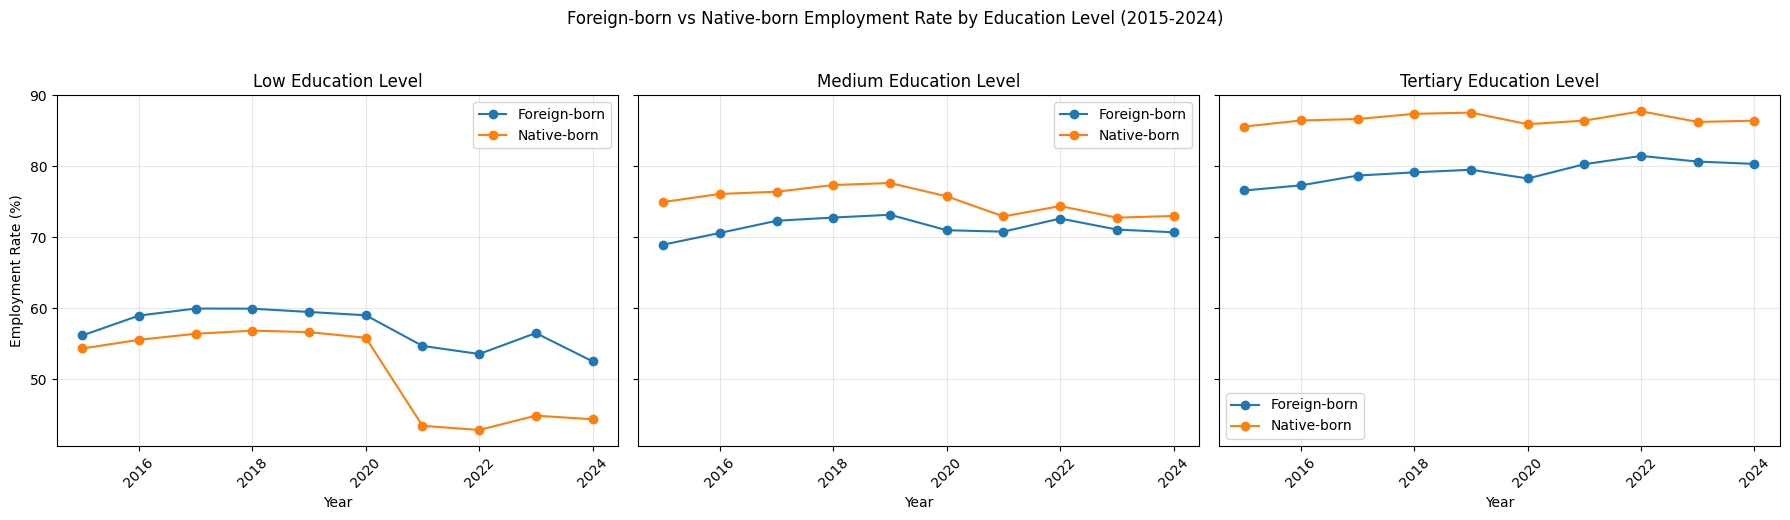

Methodology — Chart 1:
For each education level and year, the employment rate is averaged across all
countries that reported a value for that year. pandas' .mean() ignores NaN by
default (skipna=True), so a country missing data for a given year/category is
simply left out of that year's average rather than treated as zero.
Countries contributing per year (per category):

Low:
             Low_Foreign  Low_Native
TIME_PERIOD                         
2015                  28          31
2016                  28          30
2017                  28          30
2018                  27          29
2019                  28          30
2020                  31          33
2021                  30          32
2022                  29          30
2023                  30          35
2024                  33          34

Medium:
             Medium_Foreign  Medium_Native
TIME_PERIOD                               
2015                     31             31
2016                     30            

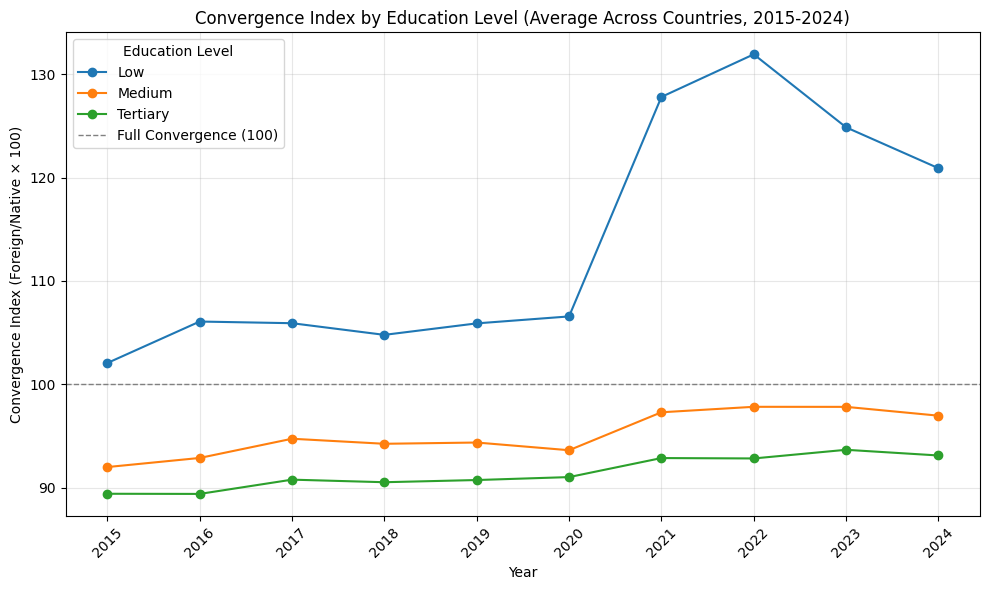

Methodology — Chart 2:
The convergence index is computed per country-year-category as
(Foreign / Native) * 100. Rows where Native is 0 or NaN produce an undefined
ratio; these are converted to NaN and dropped before averaging, so they do not
distort the yearly mean. Each plotted line is the mean of the index across all
countries with a valid value in that year, for that education level.
Number of countries contributing to the index, per year and category:
             Low  Medium  Tertiary
TIME_PERIOD                       
2015          28      31        31
2016          28      30        30
2017          28      30        30
2018          27      29        29
2019          28      30        30
2020          31      33        33
2021          30      32        32
2022          29      30        30
2023          30      35        35
2024          33      34        34



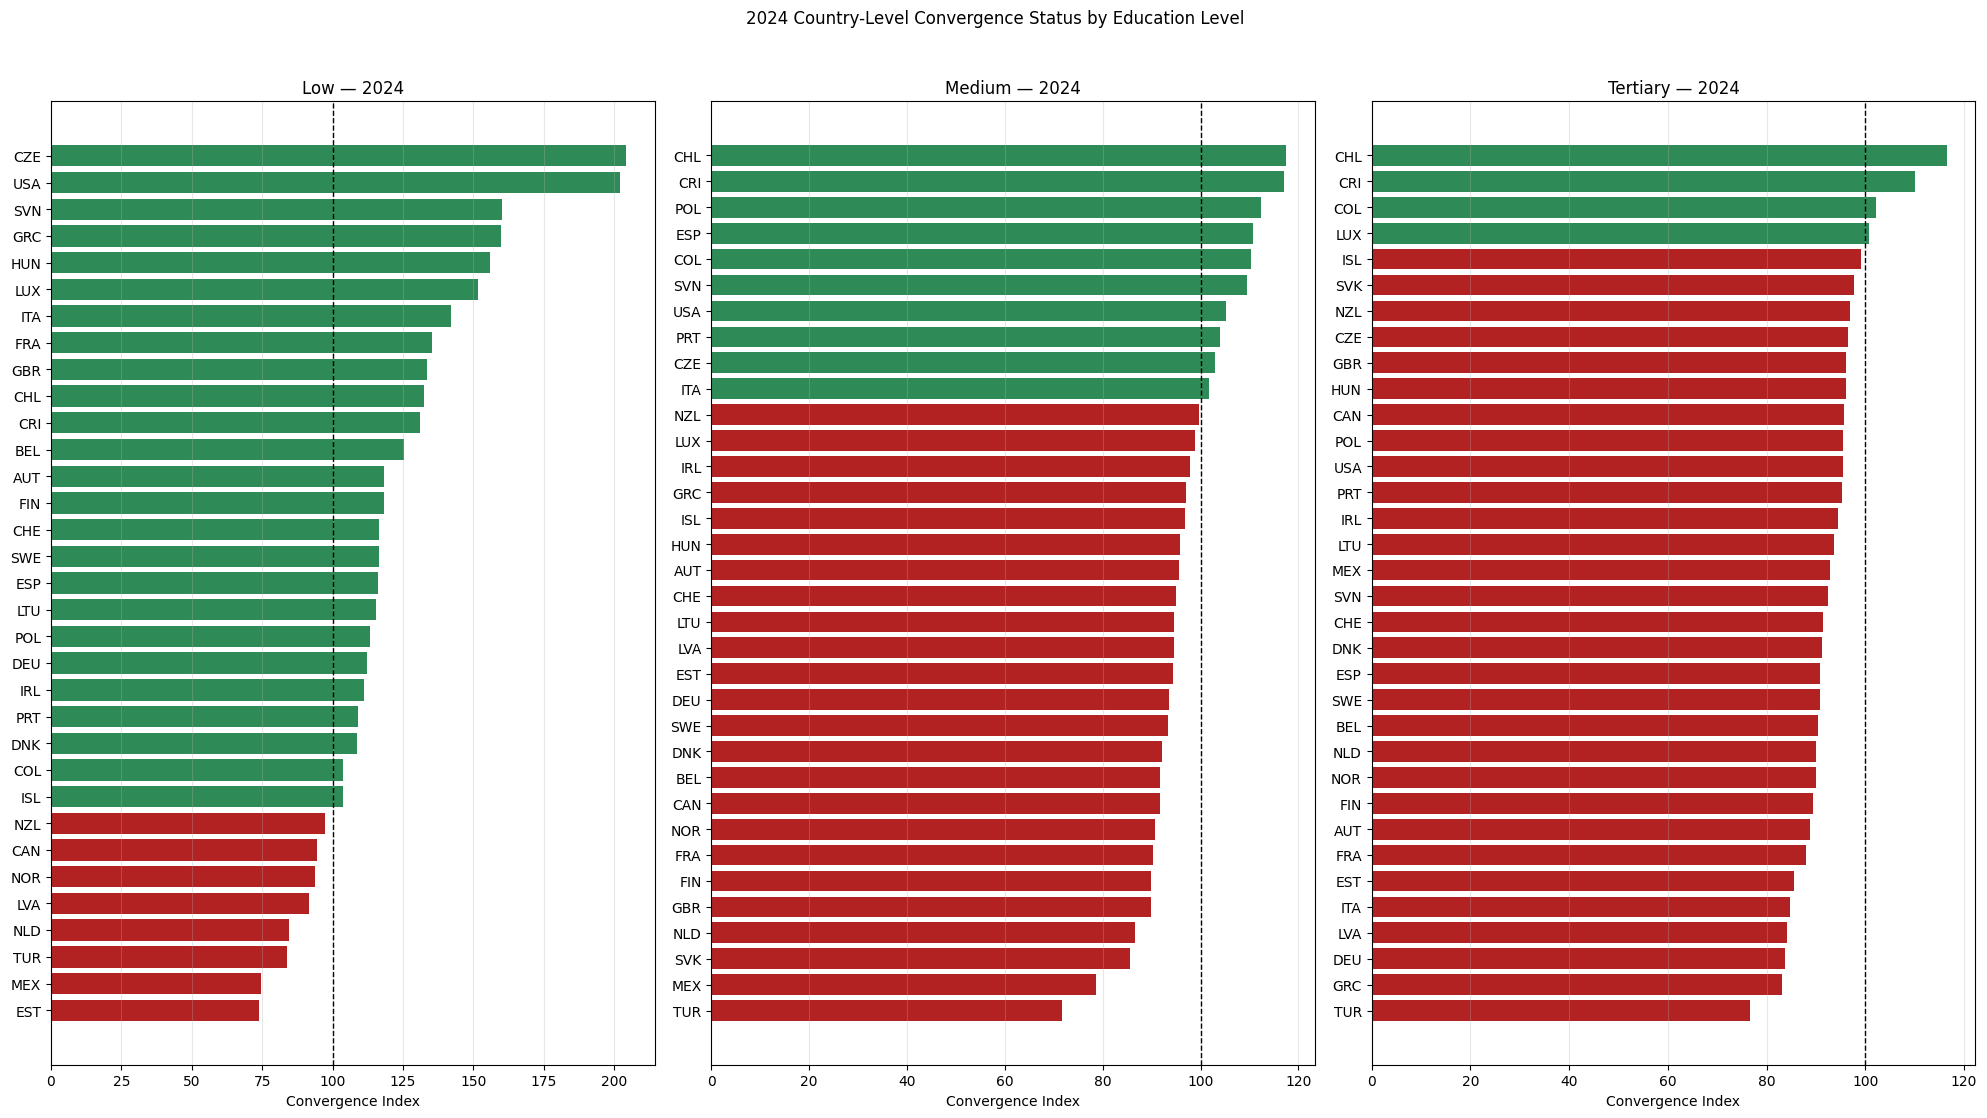

Methodology — Chart 3:
Each panel shows the 2024 convergence index by country for one education level.
Countries with a missing or undefined index value for 2024 are excluded from the
chart entirely (not shown as 0), so the bars reflect only countries with valid data.
Low: 33 out of 39 total countries shown.
Medium: 34 out of 39 total countries shown.
Tertiary: 34 out of 39 total countries shown.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 0. YEAR FILTER AND CATEGORIES
# ============================================================

result["TIME_PERIOD"] = result["TIME_PERIOD"].astype(int)
res = result[(result["TIME_PERIOD"] >= 2015) & (result["TIME_PERIOD"] <= 2024)].copy()

categories = ["Low", "Medium", "Tertiary"]
colors_map = {"Low": "tab:blue", "Medium": "tab:orange", "Tertiary": "tab:green"}

# ============================================================
# 1. CHART: FOREIGN vs NATIVE TREND FOR EACH EDUCATION LEVEL (3 panels)
# NaNs are automatically excluded inside groupby().mean() (skipna=True)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
coverage_trend = {}

for ax, cat in zip(axes, categories):
    f_col, n_col = f"{cat}_Foreign", f"{cat}_Native"
    yearly = res.groupby("TIME_PERIOD")[[f_col, n_col]].mean()
    coverage_trend[cat] = res.groupby("TIME_PERIOD")[[f_col, n_col]].apply(lambda d: d.notna().sum())

    ax.plot(yearly.index, yearly[f_col], marker="o", label="Foreign-born")
    ax.plot(yearly.index, yearly[n_col], marker="o", label="Native-born")
    ax.set_title(f"{cat} Education Level")
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

axes[0].set_ylabel("Employment Rate (%)")
fig.suptitle("Foreign-born vs Native-born Employment Rate by Education Level (2015-2024)", y=1.03)
plt.tight_layout()
plt.show()

print("Methodology — Chart 1:")
print("For each education level and year, the employment rate is averaged across all")
print("countries that reported a value for that year. pandas' .mean() ignores NaN by")
print("default (skipna=True), so a country missing data for a given year/category is")
print("simply left out of that year's average rather than treated as zero.")
print("Countries contributing per year (per category):")
for cat in categories:
    print(f"\n{cat}:")
    print(coverage_trend[cat])
print()

# ============================================================
# 2. CONVERGENCE INDEX FOR EACH EDUCATION LEVEL (Foreign/Native * 100)
# NOTE: if Native = 0 or NaN, the ratio becomes undefined (NaN/inf).
# These cases are explicitly converted to NaN and excluded before
# averaging, so they cannot bias the index.
# ============================================================

index_by_year = {}
coverage_by_year = {}

for cat in categories:
    f_col, n_col = f"{cat}_Foreign", f"{cat}_Native"
    idx_col = f"{cat}_Index"

    # ratio is undefined when Native is 0 -> convert to NaN
    ratio = res[f_col] / res[n_col].replace(0, np.nan)
    ratio = ratio.replace([np.inf, -np.inf], np.nan)
    res[idx_col] = ratio * 100

    index_by_year[cat] = res.groupby("TIME_PERIOD")[idx_col].mean()
    coverage_by_year[cat] = res.groupby("TIME_PERIOD")[idx_col].apply(lambda s: s.notna().sum())

plt.figure(figsize=(10, 6))
for cat in categories:
    plt.plot(index_by_year[cat].index, index_by_year[cat].values,
              marker="o", label=f"{cat}", color=colors_map[cat])
plt.axhline(100, color="gray", linestyle="--", linewidth=1, label="Full Convergence (100)")
plt.title("Convergence Index by Education Level (Average Across Countries, 2015-2024)")
plt.xlabel("Year")
plt.ylabel("Convergence Index (Foreign/Native × 100)")
plt.legend(title="Education Level")
plt.grid(alpha=0.3)
plt.xticks(index_by_year["Low"].index, rotation=45)
plt.tight_layout()
plt.show()

coverage_df = pd.DataFrame(coverage_by_year)
print("Methodology — Chart 2:")
print("The convergence index is computed per country-year-category as")
print("(Foreign / Native) * 100. Rows where Native is 0 or NaN produce an undefined")
print("ratio; these are converted to NaN and dropped before averaging, so they do not")
print("distort the yearly mean. Each plotted line is the mean of the index across all")
print("countries with a valid value in that year, for that education level.")
print("Number of countries contributing to the index, per year and category:")
print(coverage_df)
print()

# ============================================================
# 3. 2024: CONVERGENCE INDEX BY COUNTRY FOR EACH EDUCATION LEVEL
# (3 horizontal bar charts). Countries with no valid 2024 index
# value are dropped rather than shown as zero.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, res["REF_AREA"].nunique() * 0.28)))
counts_2024 = {}

for ax, cat in zip(axes, categories):
    idx_col = f"{cat}_Index"
    data_2024 = res[res["TIME_PERIOD"] == 2024][["REF_AREA", idx_col]].dropna()
    data_2024 = data_2024.sort_values(idx_col)
    counts_2024[cat] = len(data_2024)

    bar_colors = ["firebrick" if v < 100 else "seagreen" for v in data_2024[idx_col]]
    ax.barh(data_2024["REF_AREA"], data_2024[idx_col], color=bar_colors)
    ax.axvline(100, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{cat} — 2024")
    ax.set_xlabel("Convergence Index")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("2024 Country-Level Convergence Status by Education Level", y=1.02)
plt.tight_layout()
plt.show()

print("Methodology — Chart 3:")
print("Each panel shows the 2024 convergence index by country for one education level.")
print("Countries with a missing or undefined index value for 2024 are excluded from the")
print("chart entirely (not shown as 0), so the bars reflect only countries with valid data.")
total_countries = res["REF_AREA"].nunique()
for cat in categories:
    print(f"{cat}: {counts_2024[cat]} out of {total_countries} total countries shown.")

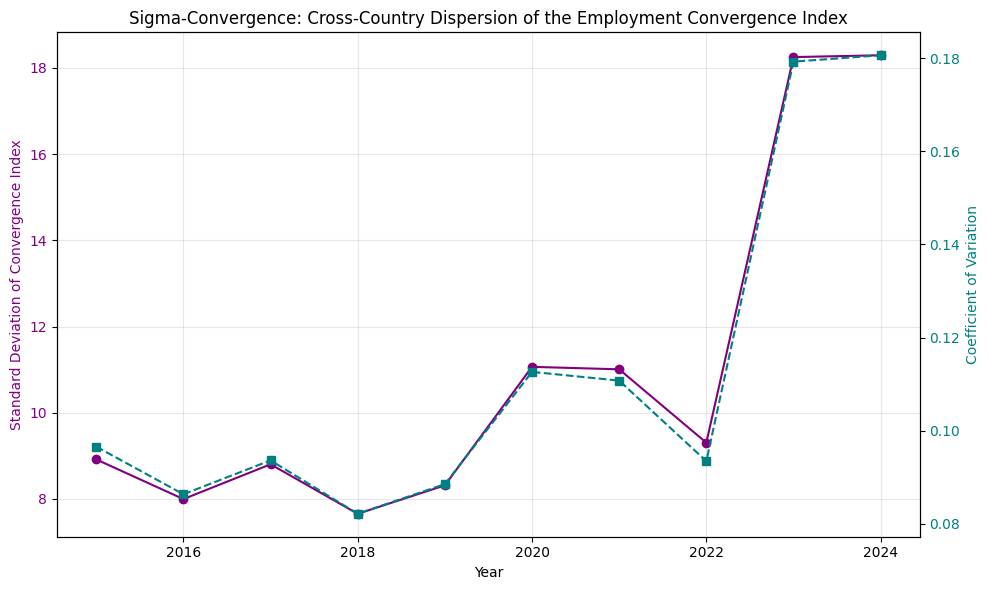

Methodology — A1 (Sigma-Convergence):
Standard deviation and coefficient of variation (std/mean) of the Total_Index are
computed across countries for each year, using only countries with a valid (non-NaN)
index value that year. A falling standard deviation indicates countries are becoming
more similar to each other over time (sigma-convergence), independent of whether the
average level itself is rising or falling. This is distinct from the mean-index trend
plotted earlier: the average can improve while dispersion stays flat or widens, or vice versa.



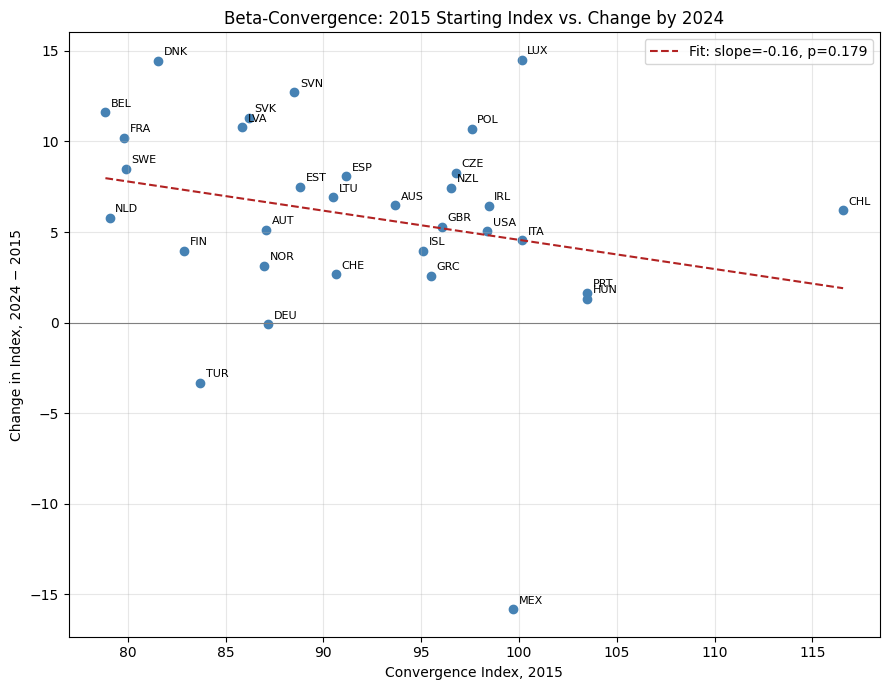

Methodology — A2 (Beta-Convergence):
Only countries with a valid Total_Index in BOTH 2015 and 2024 are included (paired
comparison) — countries missing either year are dropped rather than imputed.
A simple OLS regression of the 2015-2024 change on the 2015 starting level gives
slope = -0.161 (p = 0.179, R² = 0.059).
A negative, statistically significant slope would indicate 'catch-up' dynamics —
countries that started furthest behind gained the most. A flat or positive slope
suggests the gap is persistent or widening for initially-lagging countries.



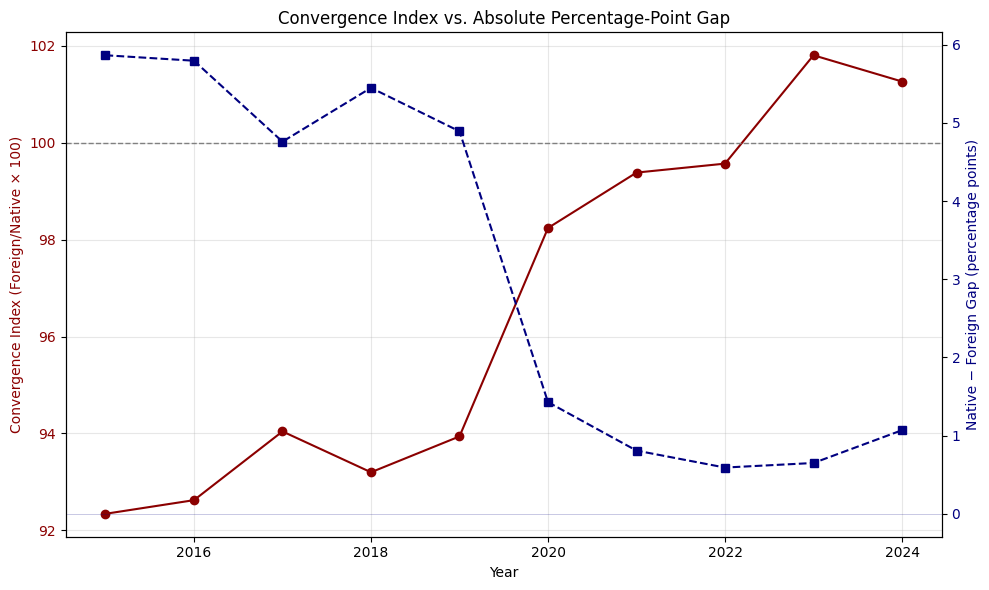

Methodology — A3 (Ratio Index vs. Absolute Gap):
The ratio index (Foreign/Native × 100) and the absolute gap (Native − Foreign, in
percentage points) are both averaged across countries with valid data per year.
These two measures are not always consistent: the ratio index is sensitive to the
level of the Native rate (a small denominator inflates the ratio even for a modest
gap), while the percentage-point gap is unaffected by that scaling. If the two series
diverge in direction, that signals the choice of metric is affecting the conclusion,
not just the underlying trend.



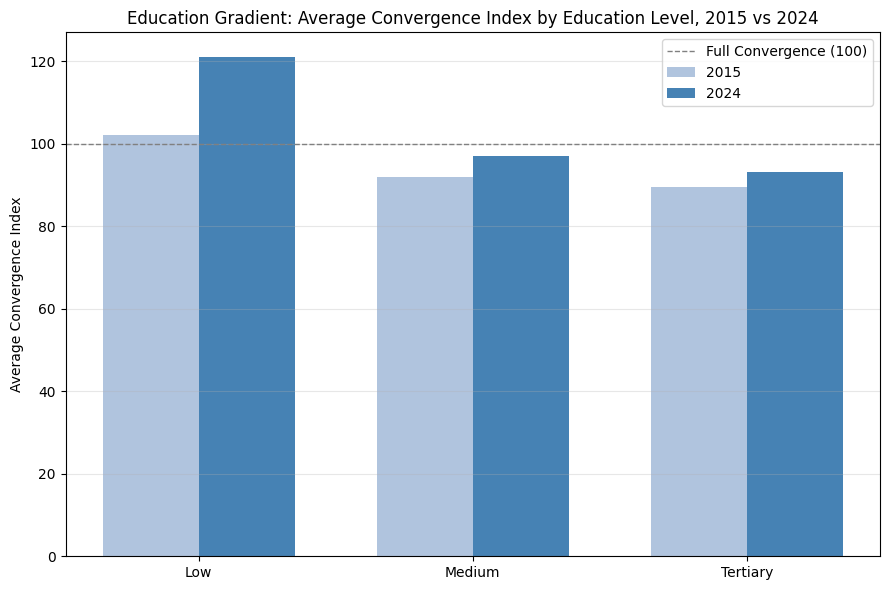

Methodology — A4 (Education Gradient):
For 2015 and 2024 separately, the convergence index is averaged across all countries
with a valid value for that education level and year (NaNs excluded, not zeroed).
This tests whether more-educated foreign-born individuals face a SMALLER or LARGER
relative employment gap than less-educated ones. A pattern where Tertiary sits further
below 100 than Low would be consistent with the 'brain waste' phenomenon documented in
migration economics — credential recognition and licensing barriers disproportionately
affecting highly-educated immigrants.
2015 averages: {'Low_Index': 102.06284929335514, 'Medium_Index': 91.99796979811647, 'Tertiary_Index': 89.41495810544465}
2024 averages: {'Low_Index': 120.9091820066352, 'Medium_Index': 96.96865680754618, 'Tertiary_Index': 93.11812834664205}



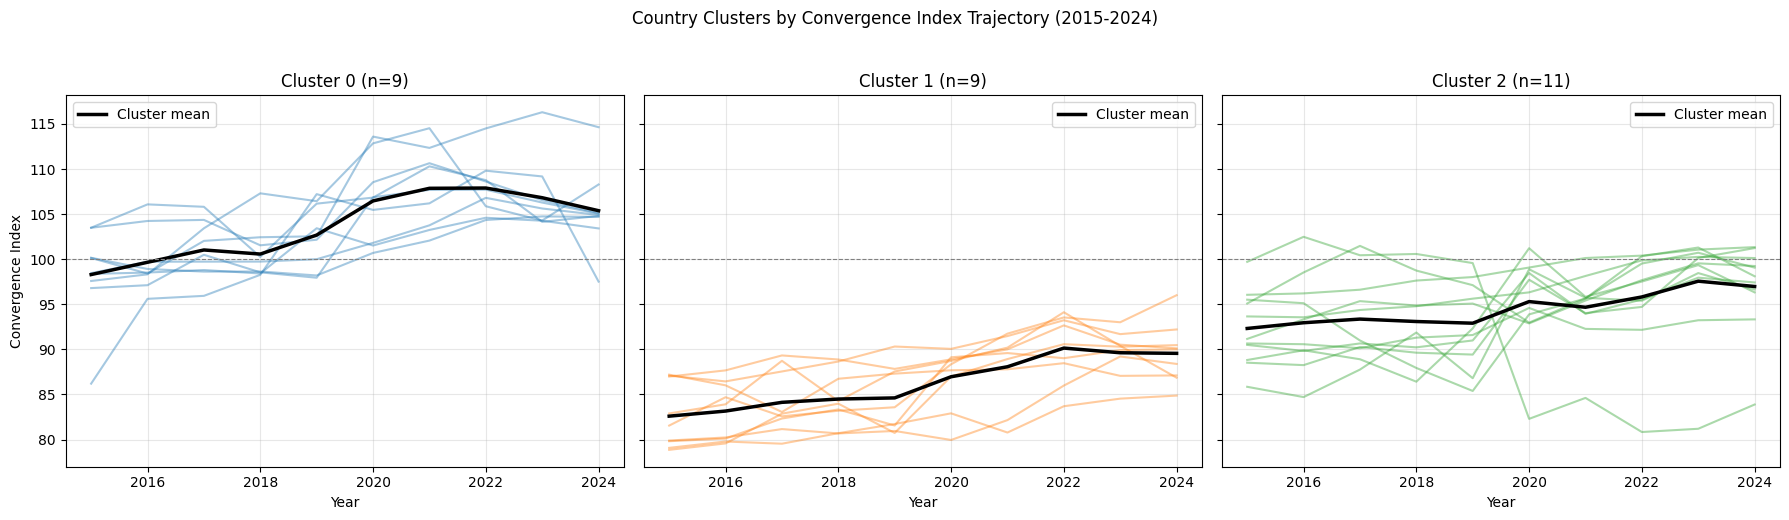

Methodology — A5 (Clustering):
Only countries with valid Total_Index data in at least 8 of the 10 years are included,
to avoid clustering on mostly-imputed trajectories; the small remaining gaps are filled
by linear interpolation across years (not carried from other countries). Each country's
standardized 10-year index trajectory is clustered into 3 groups via k-means. This is a
descriptive grouping, not a causal one — it separates countries into rough regimes
(e.g., consistently near/above full convergence, persistently lagging, or volatile),
which is easier to read than 25+ overlapping lines on one chart.
Countries excluded for insufficient data: ['CAN', 'CHL', 'COL', 'CRI', 'EU27_2020', 'HRV', 'ISR', 'KOR', 'NZL', 'TUR']



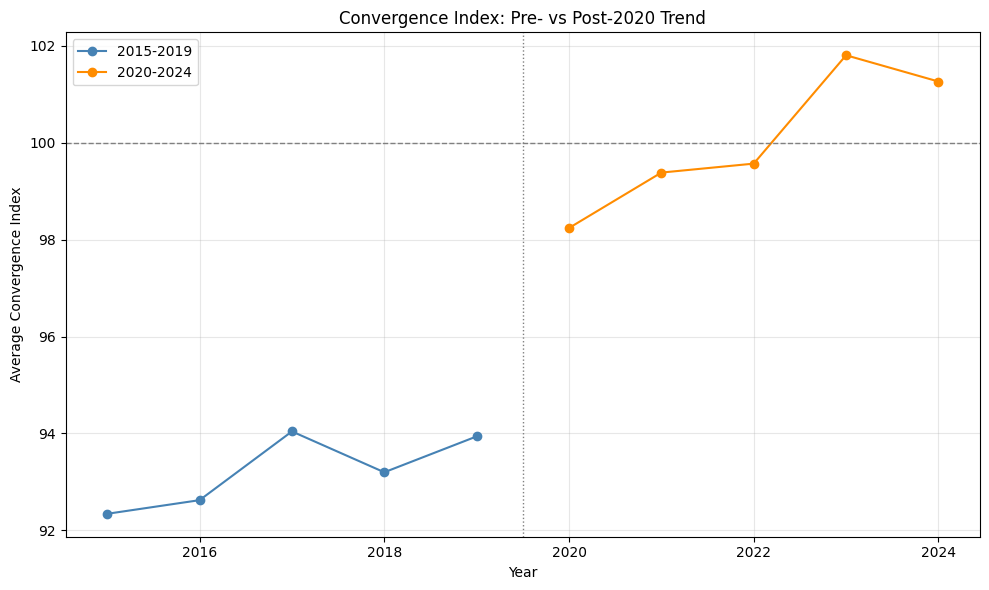

Methodology — A6 (Structural Break):
The 2015-2024 average index series is split at 2020 and a separate linear trend
(index ~ year) is fitted to each sub-period using ordinary least squares.
Pre-2020 slope: 0.377 per year (p=0.118, R²=0.613)
Post-2020 slope: 0.847 per year (p=0.028, R²=0.843)
This checks whether the overall 2015-2024 trend is a steady structural process or
mostly driven by a COVID-era shock and mechanical recovery — foreign-born employment
is well documented to have been hit harder in many economies in 2020-2021, which can
produce an apparent 'convergence' or 'divergence' pattern that is really just a
temporary disruption rather than a persistent trend.



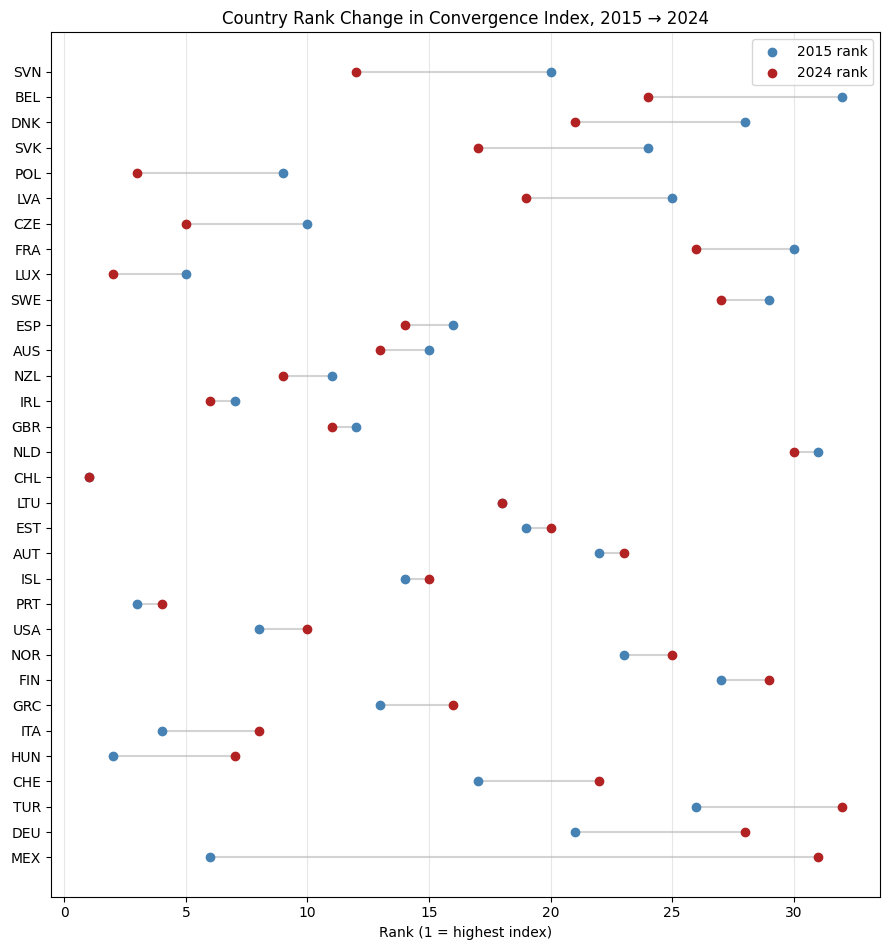

Methodology — A7 (Rank Change):
Countries are ranked by Total_Index within each year (rank 1 = highest index), using
only the paired 2015/2024 sample already built for the beta-convergence chart (both
years non-missing). Rank_Change = Rank_2015 − Rank_2024, so a positive value means the
country moved UP in relative standing between 2015 and 2024. This complements the
scatter chart by making it easy to read off exactly who moved and by how much, without
needing to compare raw index values across countries.



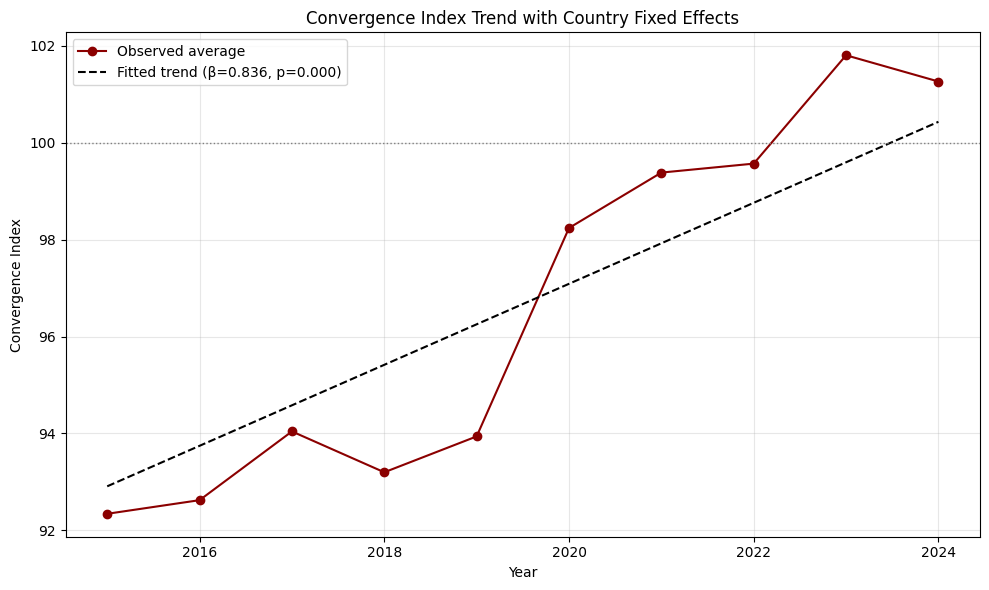

Methodology — A8 (Statistical Test):
An OLS regression of Total_Index on year (centered) with country fixed effects
(C(REF_AREA)) is estimated on all country-year observations with a valid index value.
Country fixed effects absorb persistent, country-specific differences in the index
level, so the year coefficient isolates the WITHIN-country trend over time rather than
compositional shifts (e.g., which countries happen to report data in which years).
Year coefficient: 0.8361 index points per year (p = 0.0000).
A significant negative or positive coefficient supports treating the observed average
trend as a genuine within-country pattern rather than an artifact of unbalanced
country coverage across years; a non-significant coefficient means the apparent trend
in the earlier charts should be read with caution.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# SETUP (assumes `res` already exists from earlier steps with
# Total_Foreign, Total_Native, Low/Medium/Tertiary _Foreign/_Native,
# REF_AREA, TIME_PERIOD for 2015-2024)
# ============================================================

categories = ["Low", "Medium", "Tertiary"]
colors_map = {"Low": "tab:blue", "Medium": "tab:orange", "Tertiary": "tab:green"}

# Recompute Total_Index and category indices cleanly (NaN-safe)
ratio_total = res["Total_Foreign"] / res["Total_Native"].replace(0, np.nan)
res["Total_Index"] = ratio_total.replace([np.inf, -np.inf], np.nan) * 100

for cat in categories:
    f_col, n_col = f"{cat}_Foreign", f"{cat}_Native"
    r = res[f_col] / res[n_col].replace(0, np.nan)
    res[f"{cat}_Index"] = r.replace([np.inf, -np.inf], np.nan) * 100


# ============================================================
# A1. SIGMA-CONVERGENCE — dispersion of the index across countries
# ============================================================

sigma_by_year = res.groupby("TIME_PERIOD")["Total_Index"].std()
cv_by_year = res.groupby("TIME_PERIOD")["Total_Index"].apply(
    lambda s: s.std() / s.mean() if s.mean() not in (0, np.nan) else np.nan
)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(sigma_by_year.index, sigma_by_year.values, marker="o", color="purple", label="Std. Dev. of Index")
ax1.set_xlabel("Year")
ax1.set_ylabel("Standard Deviation of Convergence Index", color="purple")
ax1.tick_params(axis='y', labelcolor="purple")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(cv_by_year.index, cv_by_year.values, marker="s", color="teal", linestyle="--", label="Coefficient of Variation")
ax2.set_ylabel("Coefficient of Variation", color="teal")
ax2.tick_params(axis='y', labelcolor="teal")

plt.title("Sigma-Convergence: Cross-Country Dispersion of the Employment Convergence Index")
fig.tight_layout()
plt.show()

print("Methodology — A1 (Sigma-Convergence):")
print("Standard deviation and coefficient of variation (std/mean) of the Total_Index are")
print("computed across countries for each year, using only countries with a valid (non-NaN)")
print("index value that year. A falling standard deviation indicates countries are becoming")
print("more similar to each other over time (sigma-convergence), independent of whether the")
print("average level itself is rising or falling. This is distinct from the mean-index trend")
print("plotted earlier: the average can improve while dispersion stays flat or widens, or vice versa.")
print()


# ============================================================
# A2. BETA-CONVERGENCE — do lagging countries catch up faster?
# x = each country's 2015 index, y = change in index (2024 - 2015)
# ============================================================

pivot_idx = res.pivot_table(index="REF_AREA", columns="TIME_PERIOD", values="Total_Index")
beta_df = pivot_idx[[2015, 2024]].dropna()
beta_df["Change"] = beta_df[2024] - beta_df[2015]

slope, intercept, r_value, p_value, std_err = stats.linregress(beta_df[2015], beta_df["Change"])

plt.figure(figsize=(9, 7))
plt.scatter(beta_df[2015], beta_df["Change"], color="steelblue")
for country in beta_df.index:
    plt.annotate(country, (beta_df.loc[country, 2015], beta_df.loc[country, "Change"]),
                 fontsize=8, xytext=(4, 4), textcoords="offset points")

x_line = np.linspace(beta_df[2015].min(), beta_df[2015].max(), 50)
plt.plot(x_line, intercept + slope * x_line, color="firebrick", linestyle="--",
          label=f"Fit: slope={slope:.2f}, p={p_value:.3f}")
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Beta-Convergence: 2015 Starting Index vs. Change by 2024")
plt.xlabel("Convergence Index, 2015")
plt.ylabel("Change in Index, 2024 − 2015")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Methodology — A2 (Beta-Convergence):")
print("Only countries with a valid Total_Index in BOTH 2015 and 2024 are included (paired")
print("comparison) — countries missing either year are dropped rather than imputed.")
print(f"A simple OLS regression of the 2015-2024 change on the 2015 starting level gives")
print(f"slope = {slope:.3f} (p = {p_value:.3f}, R² = {r_value**2:.3f}).")
print("A negative, statistically significant slope would indicate 'catch-up' dynamics —")
print("countries that started furthest behind gained the most. A flat or positive slope")
print("suggests the gap is persistent or widening for initially-lagging countries.")
print()


# ============================================================
# A3. ABSOLUTE GAP alongside the RATIO index
# ============================================================

res["Gap_pp"] = res["Total_Native"] - res["Total_Foreign"]  # percentage-point gap
gap_by_year = res.groupby("TIME_PERIOD")["Gap_pp"].mean()
index_by_year_total = res.groupby("TIME_PERIOD")["Total_Index"].mean()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(index_by_year_total.index, index_by_year_total.values, marker="o", color="darkred", label="Ratio Index")
ax1.axhline(100, color="gray", linestyle="--", linewidth=1)
ax1.set_ylabel("Convergence Index (Foreign/Native × 100)", color="darkred")
ax1.tick_params(axis='y', labelcolor="darkred")
ax1.set_xlabel("Year")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(gap_by_year.index, gap_by_year.values, marker="s", color="navy", linestyle="--", label="Absolute Gap (pp)")
ax2.axhline(0, color="navy", linewidth=0.5, alpha=0.3)
ax2.set_ylabel("Native − Foreign Gap (percentage points)", color="navy")
ax2.tick_params(axis='y', labelcolor="navy")

plt.title("Convergence Index vs. Absolute Percentage-Point Gap")
fig.tight_layout()
plt.show()

print("Methodology — A3 (Ratio Index vs. Absolute Gap):")
print("The ratio index (Foreign/Native × 100) and the absolute gap (Native − Foreign, in")
print("percentage points) are both averaged across countries with valid data per year.")
print("These two measures are not always consistent: the ratio index is sensitive to the")
print("level of the Native rate (a small denominator inflates the ratio even for a modest")
print("gap), while the percentage-point gap is unaffected by that scaling. If the two series")
print("diverge in direction, that signals the choice of metric is affecting the conclusion,")
print("not just the underlying trend.")
print()


# ============================================================
# A4. EDUCATION GRADIENT — is the gap larger for higher education?
# ============================================================

grad_2015 = res[res["TIME_PERIOD"] == 2015][[f"{c}_Index" for c in categories]].mean()
grad_2024 = res[res["TIME_PERIOD"] == 2024][[f"{c}_Index" for c in categories]].mean()

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(x - width/2, grad_2015.values, width, label="2015", color="lightsteelblue")
plt.bar(x + width/2, grad_2024.values, width, label="2024", color="steelblue")
plt.axhline(100, color="gray", linestyle="--", linewidth=1, label="Full Convergence (100)")
plt.xticks(x, categories)
plt.ylabel("Average Convergence Index")
plt.title("Education Gradient: Average Convergence Index by Education Level, 2015 vs 2024")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Methodology — A4 (Education Gradient):")
print("For 2015 and 2024 separately, the convergence index is averaged across all countries")
print("with a valid value for that education level and year (NaNs excluded, not zeroed).")
print("This tests whether more-educated foreign-born individuals face a SMALLER or LARGER")
print("relative employment gap than less-educated ones. A pattern where Tertiary sits further")
print("below 100 than Low would be consistent with the 'brain waste' phenomenon documented in")
print("migration economics — credential recognition and licensing barriers disproportionately")
print("affecting highly-educated immigrants.")
print("2015 averages:", grad_2015.to_dict())
print("2024 averages:", grad_2024.to_dict())
print()


# ============================================================
# A5. COUNTRY CLUSTERING by index trajectory shape
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

traj = pivot_idx.copy()
# keep only countries with at least 8 of 10 years present, then interpolate the rest
traj = traj[traj.notna().sum(axis=1) >= 8]
traj = traj.interpolate(axis=1, limit_direction="both")

n_clusters = 3
scaler = StandardScaler()
traj_scaled = scaler.fit_transform(traj.values)
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
traj["Cluster"] = km.fit_predict(traj_scaled)

fig, axes = plt.subplots(1, n_clusters, figsize=(18, 5), sharey=True)
cluster_colors = plt.cm.tab10.colors

for c in range(n_clusters):
    ax = axes[c]
    subset = traj[traj["Cluster"] == c].drop(columns="Cluster")
    for country in subset.index:
        ax.plot(subset.columns, subset.loc[country], alpha=0.4, color=cluster_colors[c])
    ax.plot(subset.columns, subset.mean(), color="black", linewidth=2.5, label="Cluster mean")
    ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Cluster {c} (n={len(subset)})")
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Convergence Index")
fig.suptitle("Country Clusters by Convergence Index Trajectory (2015-2024)", y=1.03)
plt.tight_layout()
plt.show()

print("Methodology — A5 (Clustering):")
print("Only countries with valid Total_Index data in at least 8 of the 10 years are included,")
print("to avoid clustering on mostly-imputed trajectories; the small remaining gaps are filled")
print("by linear interpolation across years (not carried from other countries). Each country's")
print("standardized 10-year index trajectory is clustered into 3 groups via k-means. This is a")
print("descriptive grouping, not a causal one — it separates countries into rough regimes")
print("(e.g., consistently near/above full convergence, persistently lagging, or volatile),")
print("which is easier to read than 25+ overlapping lines on one chart.")
print(f"Countries excluded for insufficient data: {sorted(set(pivot_idx.index) - set(traj.index))}")
print()


# ============================================================
# A6. PRE/POST STRUCTURAL BREAK (2015-2019 vs 2020-2024)
# ============================================================

pre = res[res["TIME_PERIOD"] <= 2019]
post = res[res["TIME_PERIOD"] >= 2020]

pre_level = pre.groupby("TIME_PERIOD")["Total_Index"].mean()
post_level = post.groupby("TIME_PERIOD")["Total_Index"].mean()

slope_pre, _, r_pre, p_pre, _ = stats.linregress(pre_level.index, pre_level.values)
slope_post, _, r_post, p_post, _ = stats.linregress(post_level.index, post_level.values)

plt.figure(figsize=(10, 6))
plt.plot(pre_level.index, pre_level.values, marker="o", color="steelblue", label="2015-2019")
plt.plot(post_level.index, post_level.values, marker="o", color="darkorange", label="2020-2024")
plt.axvline(2019.5, color="gray", linestyle=":", linewidth=1)
plt.axhline(100, color="gray", linestyle="--", linewidth=1)
plt.title("Convergence Index: Pre- vs Post-2020 Trend")
plt.xlabel("Year")
plt.ylabel("Average Convergence Index")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Methodology — A6 (Structural Break):")
print("The 2015-2024 average index series is split at 2020 and a separate linear trend")
print("(index ~ year) is fitted to each sub-period using ordinary least squares.")
print(f"Pre-2020 slope: {slope_pre:.3f} per year (p={p_pre:.3f}, R²={r_pre**2:.3f})")
print(f"Post-2020 slope: {slope_post:.3f} per year (p={p_post:.3f}, R²={r_post**2:.3f})")
print("This checks whether the overall 2015-2024 trend is a steady structural process or")
print("mostly driven by a COVID-era shock and mechanical recovery — foreign-born employment")
print("is well documented to have been hit harder in many economies in 2020-2021, which can")
print("produce an apparent 'convergence' or 'divergence' pattern that is really just a")
print("temporary disruption rather than a persistent trend.")
print()


# ============================================================
# A7. RANK-CHANGE TABLE (2015 vs 2024) — dumbbell-style chart
# ============================================================

rank_df = beta_df.copy()  # already has 2015, 2024, Change for paired countries
rank_df["Rank_2015"] = rank_df[2015].rank(ascending=False)
rank_df["Rank_2024"] = rank_df[2024].rank(ascending=False)
rank_df["Rank_Change"] = rank_df["Rank_2015"] - rank_df["Rank_2024"]
rank_df = rank_df.sort_values("Rank_Change")

plt.figure(figsize=(9, max(6, len(rank_df) * 0.3)))
for i, country in enumerate(rank_df.index):
    plt.plot([rank_df.loc[country, "Rank_2015"], rank_df.loc[country, "Rank_2024"]], [i, i],
              color="lightgray", zorder=1)
plt.scatter(rank_df["Rank_2015"], range(len(rank_df)), color="steelblue", label="2015 rank", zorder=2)
plt.scatter(rank_df["Rank_2024"], range(len(rank_df)), color="firebrick", label="2024 rank", zorder=2)
plt.yticks(range(len(rank_df)), rank_df.index)
plt.xlabel("Rank (1 = highest index)")
plt.title("Country Rank Change in Convergence Index, 2015 → 2024")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Methodology — A7 (Rank Change):")
print("Countries are ranked by Total_Index within each year (rank 1 = highest index), using")
print("only the paired 2015/2024 sample already built for the beta-convergence chart (both")
print("years non-missing). Rank_Change = Rank_2015 − Rank_2024, so a positive value means the")
print("country moved UP in relative standing between 2015 and 2024. This complements the")
print("scatter chart by making it easy to read off exactly who moved and by how much, without")
print("needing to compare raw index values across countries.")
print()


# ============================================================
# A8. STATISTICAL TEST — trend significance with country fixed effects
# ============================================================

import statsmodels.formula.api as smf

reg_data = res.dropna(subset=["Total_Index"]).copy()
reg_data["Year_centered"] = reg_data["TIME_PERIOD"] - reg_data["TIME_PERIOD"].mean()

model = smf.ols("Total_Index ~ Year_centered + C(REF_AREA)", data=reg_data).fit()
year_coef = model.params["Year_centered"]
year_pval = model.pvalues["Year_centered"]

plt.figure(figsize=(10, 6))
plt.plot(index_by_year_total.index, index_by_year_total.values, marker="o", color="darkred", label="Observed average")
years_arr = np.array(sorted(reg_data["TIME_PERIOD"].unique()))
fitted_trend = model.params["Intercept"] + year_coef * (years_arr - reg_data["TIME_PERIOD"].mean())
plt.plot(years_arr, fitted_trend, color="black", linestyle="--",
          label=f"Fitted trend (β={year_coef:.3f}, p={year_pval:.3f})")
plt.axhline(100, color="gray", linestyle=":", linewidth=1)
plt.title("Convergence Index Trend with Country Fixed Effects")
plt.xlabel("Year")
plt.ylabel("Convergence Index")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Methodology — A8 (Statistical Test):")
print("An OLS regression of Total_Index on year (centered) with country fixed effects")
print("(C(REF_AREA)) is estimated on all country-year observations with a valid index value.")
print("Country fixed effects absorb persistent, country-specific differences in the index")
print("level, so the year coefficient isolates the WITHIN-country trend over time rather than")
print("compositional shifts (e.g., which countries happen to report data in which years).")
print(f"Year coefficient: {year_coef:.4f} index points per year (p = {year_pval:.4f}).")
print("A significant negative or positive coefficient supports treating the observed average")
print("trend as a genuine within-country pattern rather than an artifact of unbalanced")
print("country coverage across years; a non-significant coefficient means the apparent trend")
print("in the earlier charts should be read with caution.")

In [ ]:
import requests
import pandas as pd
from io import StringIO
from google.colab import files

# ============================================================
# 1. OECD VERİSİNİ ÇEK
# ============================================================

url = (
    "https://sdmx.oecd.org/public/rest/v1/data/"
    "OECD.ELS.IMD,DSD_MIG@DF_MIG_EMP_EDU,1.0/"
    "?startPeriod=2010"
    "&endPeriod=2024"
    "&dimensionAtObservation=AllDimensions"
)

headers = {"Accept": "text/csv"}

response = requests.get(url, headers=headers, timeout=180)
response.raise_for_status()

df = pd.read_csv(StringIO(response.text))


print("Sütunlar:", df.columns.tolist())
display(df.head(300))


Sütunlar: ['DATAFLOW', 'REF_AREA', 'CITIZENSHIP', 'FREQ', 'MEASURE', 'SEX', 'BIRTH_PLACE', 'EDUCATION_LEV', 'UNIT_MEASURE', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_STATUS', 'UNIT_MULT', 'DECIMALS']


,DATAFLOW,REF_AREA,CITIZENSHIP,FREQ,MEASURE,SEX,BIRTH_PLACE,EDUCATION_LEV,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,OBS_STATUS,UNIT_MULT,DECIMALS
0,OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0),AUS,_Z,A,EMP_WAP,_T,FB,_T,PT_POP_SUB,2023,77.509453,A,0,1.0
1,OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0),AUS,_Z,A,EMP_WAP,_T,NB,_T,PT_POP_SUB,2023,77.337906,A,0,1.0
2,OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0),AUT,_Z,A,EMP_WAP,_T,FB,_T,PT_POP_SUB,2023,69.489601,A,0,1.0
3,OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0),AUT,_Z,A,EMP_WAP,_T,NB,_T,PT_POP_SUB,2023,75.787857,A,0,1.0
4,OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0),BEL,_Z,A,EMP_WAP,_T,FB,_T,PT_POP_SUB,2023,61.416870,A,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0),COL,_Z,A,EMP_WAP,_T,FB,ISCED11_3_4,PT_POP_SUB,2024,74.257850,A,0,1.0
296,OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0),CRI,_Z,A,EMP_WAP,_T,NB,ISCED11_3_4,PT_POP_SUB,2024,59.126154,A,0,1.0
297,OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0),CRI,_Z,A,EMP_WAP,_T,FB,ISCED11_3_4,PT_POP_SUB,2024,69.197407,A,0,1.0
298,OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0),CZE,_Z,A,EMP_WAP,_T,FB,ISCED11_3_4,PT_POP_SUB,2024,83.976913,A,0,1.0
